/tmp/ipykernel_46834/251256837.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Jahr', y='pct_change', data=df, palette=colors)


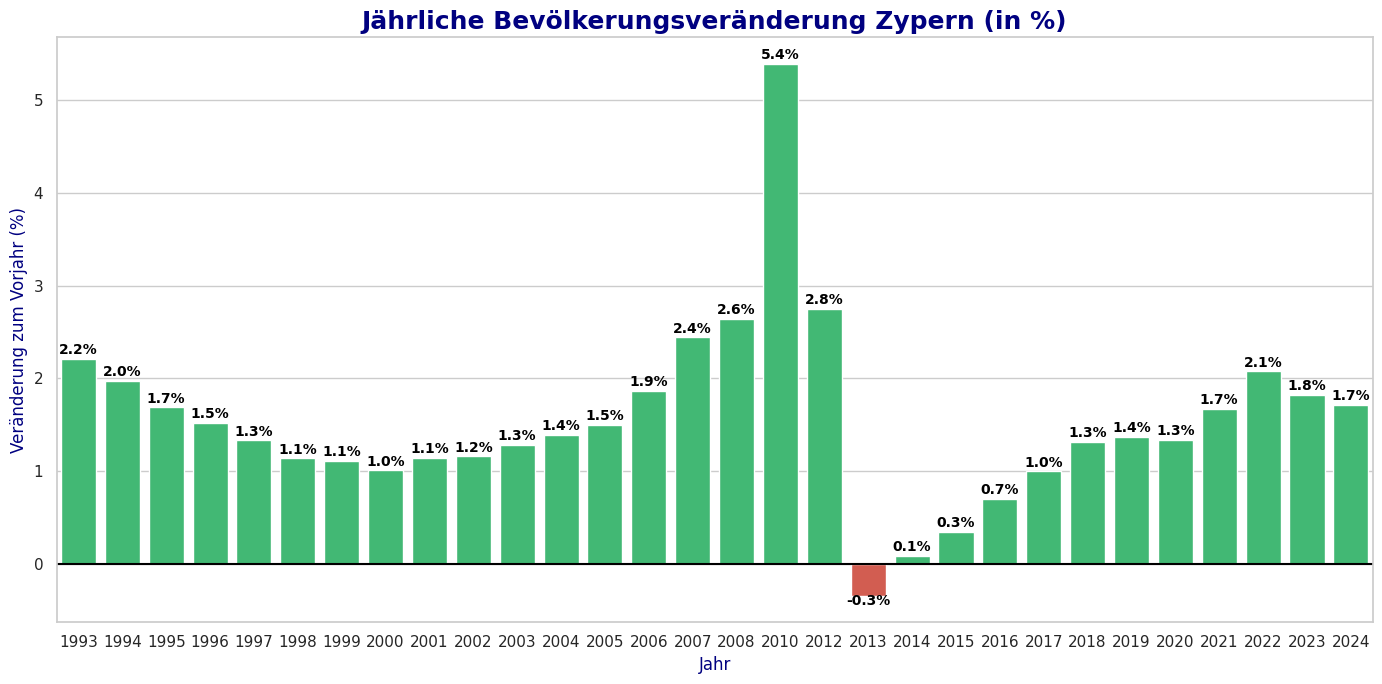

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# 1. Daten
data = {
    'Jahr': [1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2010, 2012, 2013, 2014, 2015,2016, 2017,2018,2019,2020,2021,2022,2023,2024],
    'pop_k': [619.2, 632.9, 645.4, 656.3, 666.3, 675.2, 682.9, 690.5, 697.5, 705.5, 713.7, 722.9, 733, 744, 757.9, 776.4, 796.9, 839.8, 862.9, 860.0, 860.8, 863.8, 869.9,878.6,890.2,902.4,914.5,929.8,949.1,966.4,983]
}
df = pd.DataFrame(data)

# 2. Berechnung der prozentualen Veränderung zum Vorjahr
# pct_change() ist die "Zauberfunktion" von Pandas dafür
df['pct_change'] = df['pop_k'].pct_change() * 100

# Da der erste Wert (1992) keinen Vorgänger hat, löschen wir das NaN
df = df.dropna()

# 3. Styling & Farben (Wahlgrafik-Logik)
sns.set_theme(style="whitegrid")
# Wir erstellen eine Liste: Grün für Zuwachs, Rot für Rückgang
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df['pct_change']]
elefant_blau = "#000080"

# 4. Grafik erstellen
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Jahr', y='pct_change', data=df, palette=colors)

# 5. Titel & Beschriftungen
plt.title('Jährliche Bevölkerungsveränderung Zypern (in %)', fontsize=18, fontweight='bold', color=elefant_blau)
plt.ylabel('Veränderung zum Vorjahr (%)', fontsize=12, color=elefant_blau)
plt.xlabel('Jahr', fontsize=12, color=elefant_blau)

# Null-Linie hervorheben (wie im Fernsehen)
plt.axhline(0, color='black', linewidth=1.5)

# Werte über/unter die Balken schreiben
for i, val in enumerate(df['pct_change']):
    ax.text(i, val + (0.05 if val > 0 else -0.1), f'{val:.1f}%', 
            ha='center', fontsize=10, fontweight='bold', 
            color='black' if abs(val) > 0 else 'grey')

# 6. Speichern & Anzeigen
plt.tight_layout()
plt.savefig('Zypern_prozentuale_Veraenderung.png', dpi=300)
plt.show()